# Simulation INS + VOR/DME avec CMKF

Notebook de simulation pour l'hybridation centrale inertielle (INS) et moyens de radionavigation terrestres (VOR/DME) utilisant un **Constrained Manifold Kalman Filter (CMKF)**.

## Objectifs
- Simuler la dynamique d'un aeronef equipe d'une INS et de recepteurs VOR/DME
- Comparer les performances INS seule vs INS corrigee par VOR/DME via **CMKF**
- Evaluer l'apport des contraintes de variete par rapport a l'EKF classique
- Evaluer sur 3 scenarios de trajectoire

## Differences CMKF vs EKF
- Projection sur variete apres chaque correction
- Contraintes de vitesse en virage coordonne
- Gating adaptatif selon type de manoeuvre
- Matrice de covariance projetee

## Auteur
Nicolas CUSSEAU - ENSTA ILEMS - Projet SAFRAN

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from parametres import *
from modeles_dynamique import *
from stations_sol import *
from generateur_trajectoire import *
from simulateur_ins import *

# Recharger le module CMKF pour prendre en compte les modifications
import importlib
import cmkf
importlib.reload(cmkf)
from cmkf import CMKF

from metriques import *
from visualisation import *

# Configuration matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("[OK] Imports realises (CMKF avec rechargement module)")

[OK] Imports realises (CMKF avec rechargement module)


## 2. Chargement parametres

In [2]:
# Chargement parametres par defaut
params_sim, params_ins, params_vor_dme, params_ekf = charger_parametres_defaut()

# Creation stations VOR/DME
stations = creer_stations_sol()

print("[OK] Parametres charges")
print(f"Duree simulation: {params_sim.duree_simulation} s")
print(f"Frequence IMU: {1.0/params_sim.dt_imu} Hz")
print(f"Nombre de stations: {len(stations)}")
for station in stations:
    print(f"  - {station.nom}: position {station.position} m")

[OK] Parametres charges
Duree simulation: 1200.0 s
Frequence IMU: 100.0 Hz
Nombre de stations: 3
  - Station 1: position [0. 0. 0.] m
  - Station 2: position [80000.     0.     0.] m
  - Station 3: position [40000. 60000.     0.] m


## 3. Choix scenario

Scenarios disponibles:
- **1**: Approche radiale vers station 1
- **2**: Arc circulaire autour station 1
- **3**: Transit multi-stations
- **4**: Trajectoire reelle GPS (data.csv)
- **5**: Transit balises reelles (DJL, RLP, LXI, EPL, LUL)

In [ ]:
# Selection scenario
numero_scenario = 3

if numero_scenario == 1:
    verite = generer_verite_scenario_1(params_sim)
    nom_scenario = "Approche radiale"
elif numero_scenario == 2:
    verite = generer_verite_scenario_2(params_sim)
    nom_scenario = "Arc circulaire"
elif numero_scenario == 3:
    verite = generer_verite_scenario_3(params_sim)
    nom_scenario = "Transit multi-stations"
elif numero_scenario == 4:
    verite = generer_verite_scenario_4(params_sim)
    nom_scenario = "Trajectoire reelle GPS"
else:
    verite = generer_verite_scenario_5(params_sim)
    nom_scenario = "Transit balises reelles"

print(f"[OK] Scenario {numero_scenario} genere: {nom_scenario}")
print(f"Nombre d'echantillons: {len(verite['t'])}")
print(f"Position initiale: N={verite['N'][0]:.0f} m, E={verite['E'][0]:.0f} m")
print(f"Position finale: N={verite['N'][-1]:.0f} m, E={verite['E'][-1]:.0f} m")

[OK] Scenario 3 genere: Transit multi-stations
Nombre d'echantillons: 120001
Position initiale: N=-20000 m, E=-20000 m
Position finale: N=67310 m, E=24185 m


## 4. Generation mesures IMU

In [4]:
# Generation mesures IMU bruitees
mesures_imu = generer_mesures_imu_bruitees(verite, params_ins)

print("[OK] Mesures IMU generees")
print(f"Biais gyro initial: {mesures_imu['b_g_reel'][0]:.6f} rad/s = {np.rad2deg(mesures_imu['b_g_reel'][0]):.3f} deg/s")
print(f"Biais gyro final: {mesures_imu['b_g_reel'][-1]:.6f} rad/s = {np.rad2deg(mesures_imu['b_g_reel'][-1]):.3f} deg/s")
print(f"Biais accel initial: {mesures_imu['b_a_reel'][0]:.6f} m/s^2")
print(f"Biais accel final: {mesures_imu['b_a_reel'][-1]:.6f} m/s^2")

[OK] Mesures IMU generees
Biais gyro initial: 0.005240 rad/s = 0.300 deg/s
Biais gyro final: -0.001663 rad/s = -0.095 deg/s
Biais accel initial: 0.029400 m/s^2
Biais accel final: 0.022141 m/s^2


## 5. Simulation INS seule

In [5]:
# Etat initial avec erreurs realistes
np.random.seed(42)  # Reproductibilite

# Generation erreurs aleatoires
err_N = np.random.randn() * 50.0  # 50m std
err_E = np.random.randn() * 50.0
err_V_N = np.random.randn() * 2.0  # 2 m/s std
err_V_E = np.random.randn() * 2.0
err_psi = np.random.randn() * 0.0349  # 2 deg std
err_b_g = params_ins.gyro_biais_init * 0.5  # 50% erreur estimation
err_b_a = params_ins.accel_biais_init * 0.5

x0 = np.array([
    verite['N'][0] + err_N,
    verite['E'][0] + err_E,
    verite['h'][0],
    verite['V_N'][0] + err_V_N,
    verite['V_E'][0] + err_V_E,
    verite['psi'][0] + err_psi,
    params_ins.gyro_biais_init + err_b_g,
    params_ins.accel_biais_init + err_b_a
])

print("Erreurs initiales:")
print(f"  Position: dN={err_N:.1f}m, dE={err_E:.1f}m")
print(f"  Vitesse: dV_N={err_V_N:.2f}m/s, dV_E={err_V_E:.2f}m/s")
print(f"  Cap: dpsi={np.rad2deg(err_psi):.2f}deg")
print(f"  Biais gyro: {np.rad2deg(err_b_g):.4f}deg/s")
print(f"  Biais accel: {err_b_a:.4f}m/s^2")
print()

# Integration INS seule (dead reckoning)
traj_ins_seule = integrer_ins_seule(mesures_imu, x0, params_sim, params_ins)

print("[OK] Integration INS seule terminee")
print(f"Position finale INS: N={traj_ins_seule['N'][-1]:.0f} m, E={traj_ins_seule['E'][-1]:.0f} m")
print(f"Erreur finale 2D: {np.sqrt((traj_ins_seule['N'][-1] - verite['N'][-1])**2 + (traj_ins_seule['E'][-1] - verite['E'][-1])**2):.0f} m")

Erreurs initiales:
  Position: dN=24.8m, dE=-6.9m
  Vitesse: dV_N=1.30m/s, dV_E=3.05m/s
  Cap: dpsi=-0.47deg
  Biais gyro: 0.1501deg/s
  Biais accel: 0.0147m/s^2

[OK] Integration INS seule terminee
Position finale INS: N=40110 m, E=55492 m
Erreur finale 2D: 41472 m


## 6. Simulation INS + CMKF

In [6]:
# Initialisation CMKF
cmkf = CMKF(x0, params_ekf.P0, params_ins, params_vor_dme, params_ekf)

# Reinitialisation timers stations
for station in stations:
    station.prochain_temps_mesure = 1.0 / station.frequence_mesure

# Initialisation stockage trajectoire CMKF
N_samples = len(verite['t'])
traj_cmkf = {
    't': verite['t'].copy(),
    'N': np.zeros(N_samples),
    'E': np.zeros(N_samples),
    'h': np.zeros(N_samples),
    'V_N': np.zeros(N_samples),
    'V_E': np.zeros(N_samples),
    'psi': np.zeros(N_samples),
    'b_g': np.zeros(N_samples),
    'b_a': np.zeros(N_samples)
}

# Etat initial
for i, key in enumerate(['N', 'E', 'h', 'V_N', 'V_E', 'psi', 'b_g', 'b_a']):
    traj_cmkf[key][0] = cmkf.x[i]

# Compteurs mesures
n_mesures_vor_acceptees = 0
n_mesures_vor_rejetees = 0
n_mesures_dme_acceptees = 0
n_mesures_dme_rejetees = 0

print("[INFO] Debut boucle CMKF...")

# Boucle temporelle
for k in range(1, N_samples):
    t = verite['t'][k]
    
    # Prediction CMKF
    u_accel = np.array([mesures_imu['u_accel_N'][k-1], mesures_imu['u_accel_E'][k-1]])
    cmkf.prediction(mesures_imu['u_gyro'][k-1], u_accel, params_sim.dt_imu)
    
    # Updates VOR/DME asynchrones
    for station in stations:
        if t >= station.prochain_temps_mesure:
            # Verification visibilite
            if verifier_visibilite(cmkf.x, station, params_vor_dme):
                # Etat verite pour generer mesure
                x_verite = np.array([verite['N'][k], verite['E'][k], verite['h'][k], 
                                    0, 0, 0, 0, 0])
                
                # Mesure VOR
                if station.a_vor:
                    z_vor_vrai = modele_mesure_vor(x_verite, station)
                    z_vor = z_vor_vrai + np.random.randn() * params_vor_dme.vor_sigma + params_vor_dme.vor_biais
                    accepte = cmkf.update_vor(z_vor, station)
                    if accepte:
                        n_mesures_vor_acceptees += 1
                    else:
                        n_mesures_vor_rejetees += 1
                
                # Mesure DME
                if station.a_dme:
                    z_dme_vrai = modele_mesure_dme(x_verite, station)
                    z_dme = z_dme_vrai + np.random.randn() * params_vor_dme.dme_sigma + params_vor_dme.dme_biais
                    accepte = cmkf.update_dme(z_dme, station)
                    if accepte:
                        n_mesures_dme_acceptees += 1
                    else:
                        n_mesures_dme_rejetees += 1
            
            # Prochaine mesure
            station.prochain_temps_mesure += 1.0 / station.frequence_mesure
    
    # Sauvegarde etat
    cmkf.sauvegarder_etat(t)
    for i, key in enumerate(['N', 'E', 'h', 'V_N', 'V_E', 'psi', 'b_g', 'b_a']):
        traj_cmkf[key][k] = cmkf.x[i]
    
    # Affichage progression
    if k % 10000 == 0:
        print(f"  t = {t:.1f} s ({100*k/N_samples:.1f}%)")

print("[OK] Boucle CMKF terminee")
print(f"Mesures VOR: {n_mesures_vor_acceptees} acceptees, {n_mesures_vor_rejetees} rejetees")
print(f"Mesures DME: {n_mesures_dme_acceptees} acceptees, {n_mesures_dme_rejetees} rejetees")
print(f"Position finale CMKF: N={traj_cmkf['N'][-1]:.0f} m, E={traj_cmkf['E'][-1]:.0f} m")
print(f"Erreur finale 2D: {np.sqrt((traj_cmkf['N'][-1] - verite['N'][-1])**2 + (traj_cmkf['E'][-1] - verite['E'][-1])**2):.0f} m")

[INFO] Debut boucle CMKF...
  t = 100.0 s (8.3%)
  t = 200.0 s (16.7%)
  t = 300.0 s (25.0%)
  t = 400.0 s (33.3%)
  t = 500.0 s (41.7%)
  t = 600.0 s (50.0%)
  t = 700.0 s (58.3%)
  t = 800.0 s (66.7%)
  t = 900.0 s (75.0%)
  t = 1000.0 s (83.3%)
  t = 1100.0 s (91.7%)
  t = 1200.0 s (100.0%)
[OK] Boucle CMKF terminee
Mesures VOR: 1620 acceptees, 4 rejetees
Mesures DME: 1624 acceptees, 0 rejetees
Position finale CMKF: N=67357 m, E=24161 m
Erreur finale 2D: 53 m


## 7. Calcul erreurs

In [7]:
# Calcul erreurs
erreurs_ins = calculer_erreurs(traj_ins_seule, verite)
erreurs_cmkf = calculer_erreurs(traj_cmkf, verite)

print("[OK] Erreurs calculees")

[OK] Erreurs calculees


## 8. Metriques glissantes

In [8]:
# RMSE glissant
rmse_ins_N = rmse_glissant(erreurs_ins['err_N'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_ins_E = rmse_glissant(erreurs_ins['err_E'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_ins_2D = rmse_glissant(erreurs_ins['err_2D'], params_ekf.fenetre_rmse, params_sim.dt_imu)

rmse_cmkf_N = rmse_glissant(erreurs_cmkf['err_N'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_cmkf_E = rmse_glissant(erreurs_cmkf['err_E'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_cmkf_2D = rmse_glissant(erreurs_cmkf['err_2D'], params_ekf.fenetre_rmse, params_sim.dt_imu)

rmse_ins = {'N': rmse_ins_N, 'E': rmse_ins_E, '2D': rmse_ins_2D}
rmse_cmkf = {'N': rmse_cmkf_N, 'E': rmse_cmkf_E, '2D': rmse_cmkf_2D}

# CEP glissant
cep50_ins = cep_glissant(erreurs_ins['err_N'], erreurs_ins['err_E'], 
                         params_ekf.fenetre_rmse, params_sim.dt_imu, 50)
cep50_cmkf = cep_glissant(erreurs_cmkf['err_N'], erreurs_cmkf['err_E'], 
                         params_ekf.fenetre_rmse, params_sim.dt_imu, 50)

print("[OK] Metriques glissantes calculees")

[OK] Metriques glissantes calculees


## 9. Statistiques finales

In [9]:
# Calcul statistiques
stats_ins = statistiques_finales(erreurs_ins)
stats_cmkf = statistiques_finales(erreurs_cmkf)

print("="*60)
print(f"STATISTIQUES FINALES - Scenario {numero_scenario}: {nom_scenario}")
print("="*60)

print("\n--- INS SEULE ---")
print(f"RMSE Nord:     {stats_ins['RMSE_N']:.2f} m")
print(f"RMSE Est:      {stats_ins['RMSE_E']:.2f} m")
print(f"RMSE 2D:       {stats_ins['RMSE_2D']:.2f} m")
print(f"Erreur max 2D: {stats_ins['max_2D']:.2f} m")
print(f"CEP50:         {stats_ins['CEP50']:.2f} m")
print(f"CEP95:         {stats_ins['CEP95']:.2f} m")
print(f"RMSE cap:      {stats_ins['RMSE_psi_deg']:.3f} deg")

print("\n--- INS + CMKF ---")
print(f"RMSE Nord:     {stats_cmkf['RMSE_N']:.2f} m")
print(f"RMSE Est:      {stats_cmkf['RMSE_E']:.2f} m")
print(f"RMSE 2D:       {stats_cmkf['RMSE_2D']:.2f} m")
print(f"Erreur max 2D: {stats_cmkf['max_2D']:.2f} m")
print(f"CEP50:         {stats_cmkf['CEP50']:.2f} m")
print(f"CEP95:         {stats_cmkf['CEP95']:.2f} m")
print(f"RMSE cap:      {stats_cmkf['RMSE_psi_deg']:.3f} deg")

print("\n--- AMELIORATION CMKF vs INS ---")
amelioration_rmse = (1 - stats_cmkf['RMSE_2D'] / stats_ins['RMSE_2D']) * 100
amelioration_cep50 = (1 - stats_cmkf['CEP50'] / stats_ins['CEP50']) * 100
amelioration_cep95 = (1 - stats_cmkf['CEP95'] / stats_ins['CEP95']) * 100
print(f"RMSE 2D:  {amelioration_rmse:.1f}%")
print(f"CEP50:    {amelioration_cep50:.1f}%")
print(f"CEP95:    {amelioration_cep95:.1f}%")
print("="*60)

STATISTIQUES FINALES - Scenario 3: Transit multi-stations

--- INS SEULE ---
RMSE Nord:     17405.21 m
RMSE Est:      20898.21 m
RMSE 2D:       27196.99 m
Erreur max 2D: 45102.86 m
CEP50:         19569.04 m
CEP95:         44686.27 m
RMSE cap:      113.013 deg

--- INS + CMKF ---
RMSE Nord:     173.44 m
RMSE Est:      165.30 m
RMSE 2D:       239.60 m
Erreur max 2D: 1258.23 m
CEP50:         146.95 m
CEP95:         383.58 m
RMSE cap:      107.229 deg

--- AMELIORATION CMKF vs INS ---
RMSE 2D:  99.1%
CEP50:    99.2%
CEP95:    99.1%


## 10. Visualisations

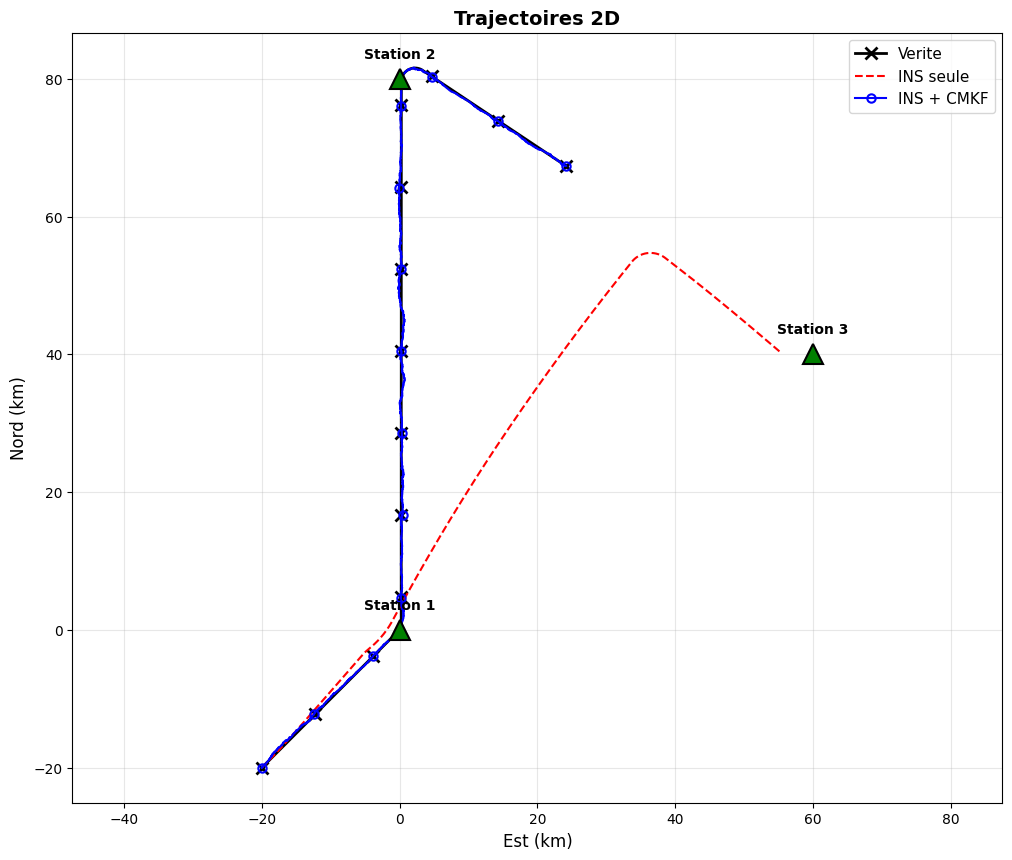

In [10]:
# Trajectoires 2D
fig1, ax1 = plot_trajectoires_2D(verite, traj_ins_seule, traj_cmkf, stations)
plt.show()

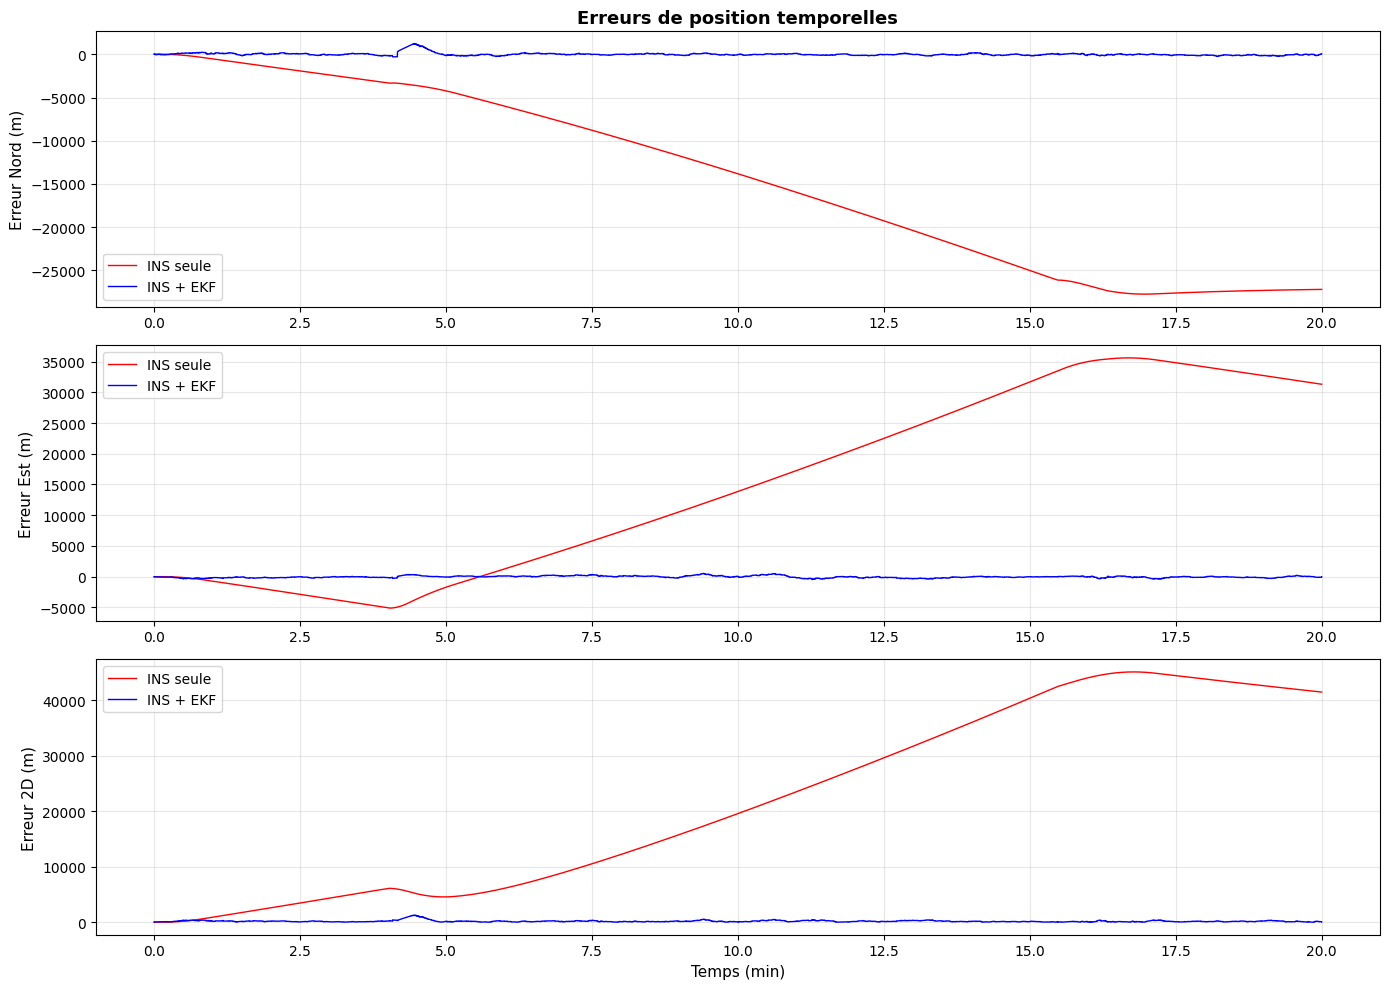

In [11]:
# Erreurs temporelles
fig2 = plot_erreurs_temporelles(verite['t'], erreurs_ins, erreurs_cmkf)
plt.show()

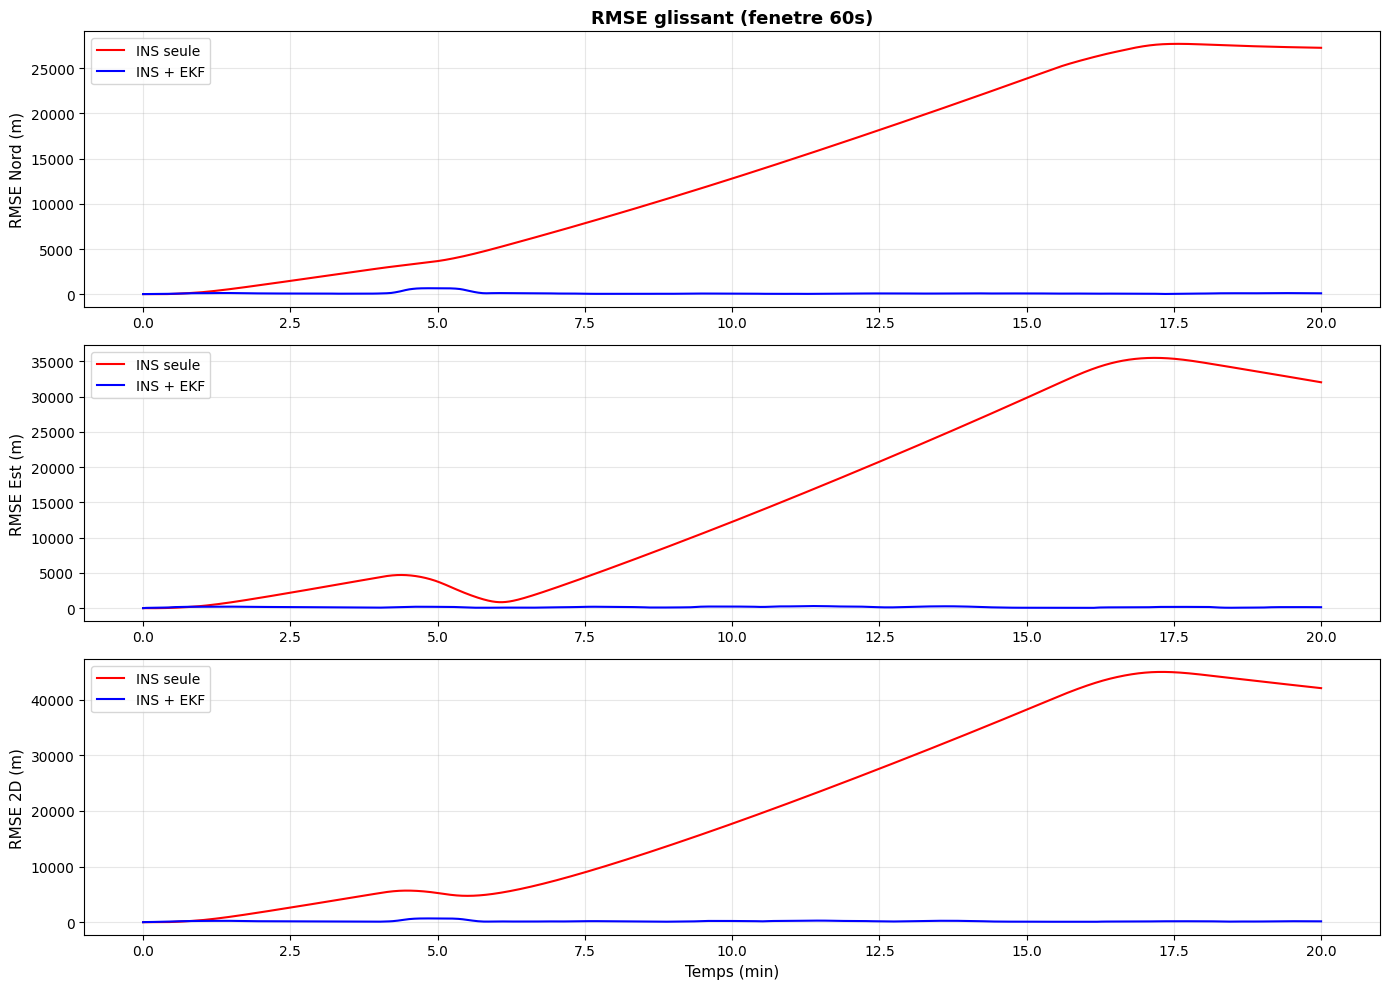

In [12]:
# RMSE glissant
fig3 = plot_rmse_glissant(verite['t'], rmse_ins, rmse_cmkf, params_ekf.fenetre_rmse)
plt.show()

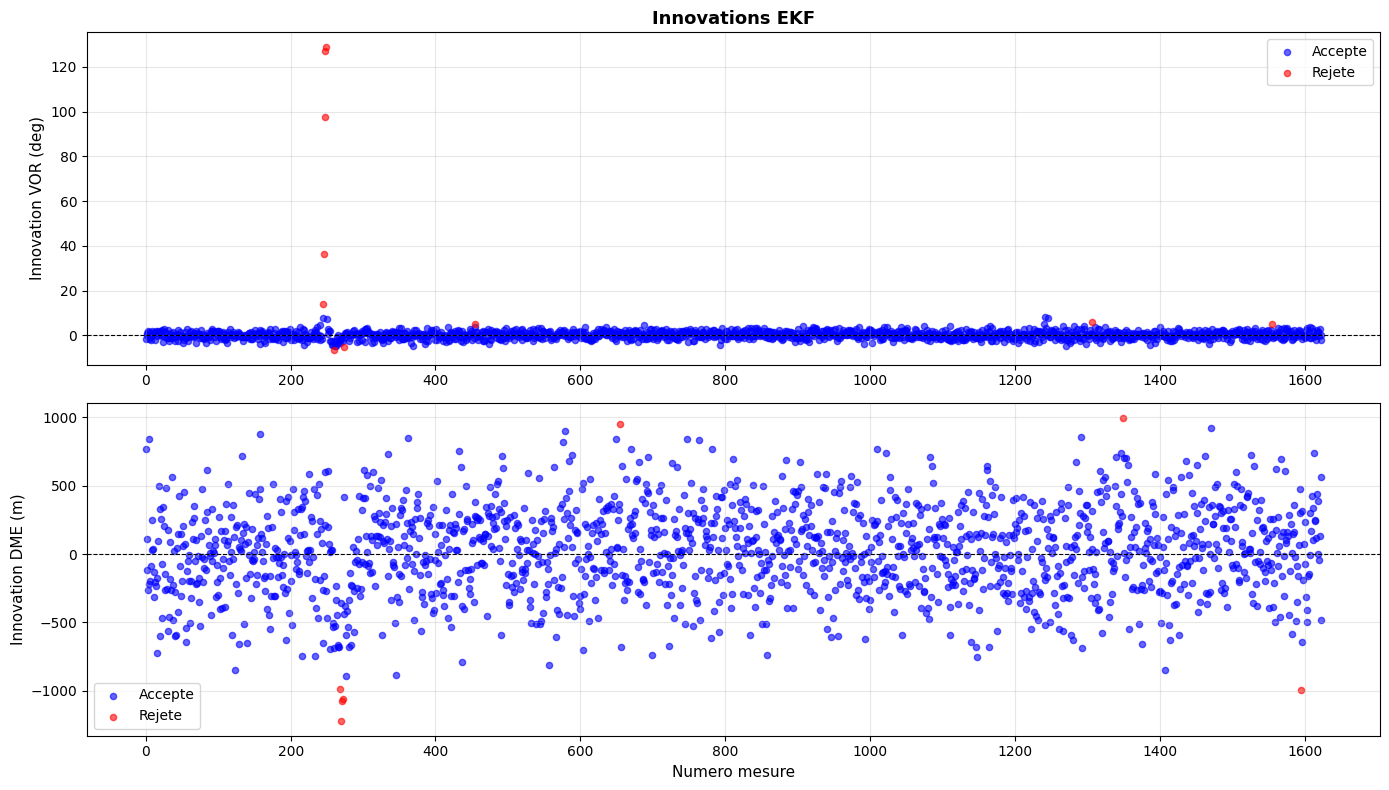

In [13]:
# Innovations CMKF
fig4 = plot_innovations_ekf(cmkf.historique)  # Fonction compatible CMKF
plt.show()

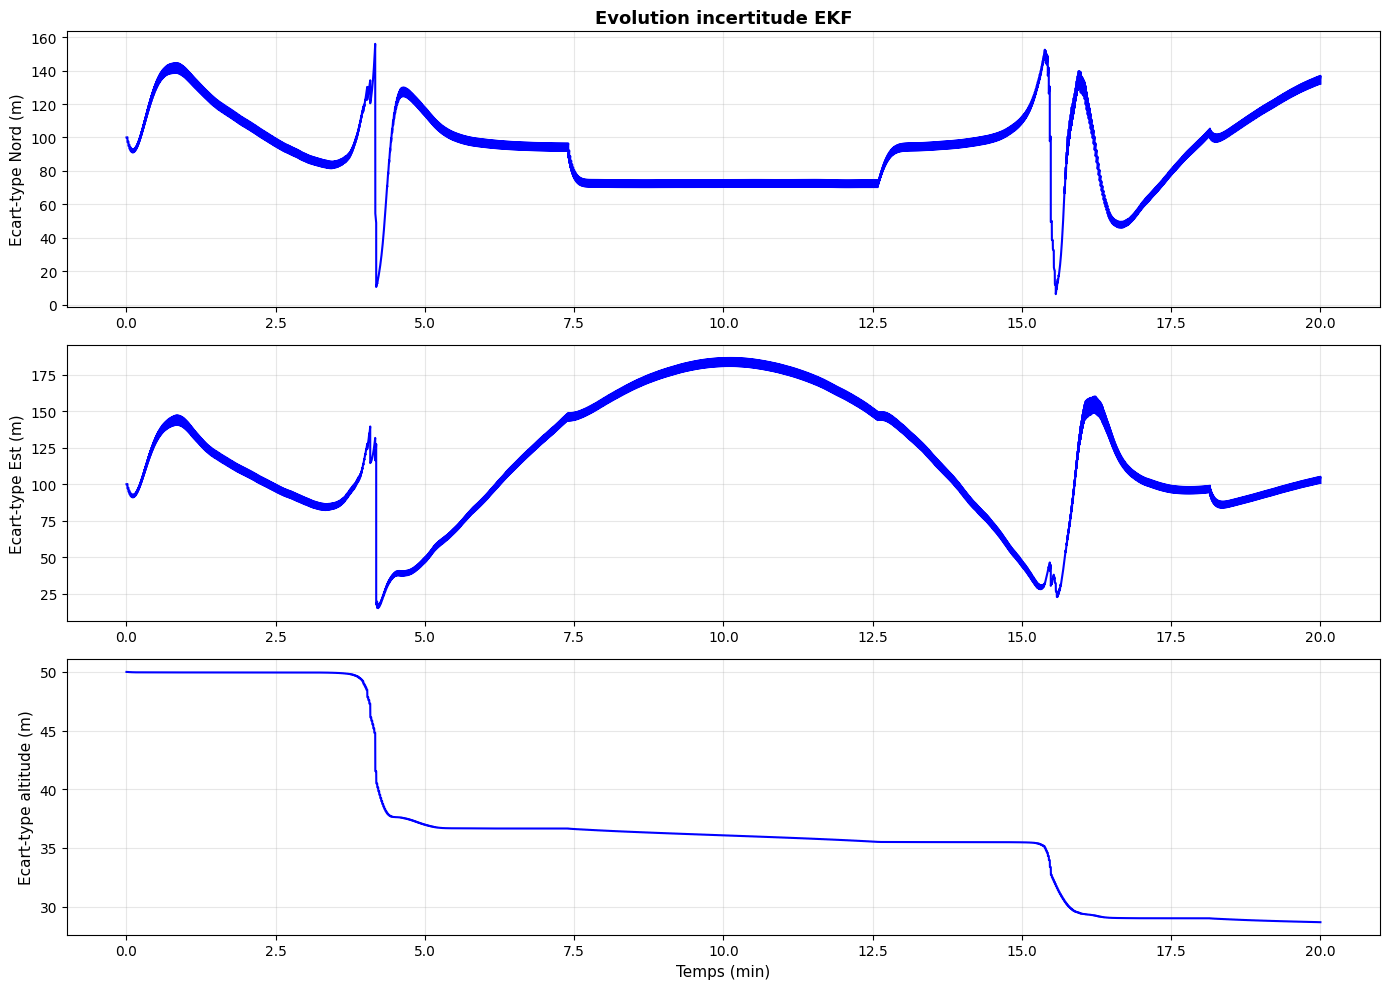

In [14]:
# Covariance CMKF
fig5 = plot_covariance_ekf(cmkf.historique)  # Fonction compatible CMKF
plt.show()

## 11. Animation

Animation des trajectoires (acceleration x10)

In [15]:
# Recharger module visualisation pour prendre en compte les corrections
import importlib
import visualisation
importlib.reload(visualisation)
from visualisation import animer_trajectoires

print('[OK] Module visualisation recharge')

[OK] Module visualisation recharge


In [ ]:
# Animation avec affichage forcé
import matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

anim = animer_trajectoires(verite, traj_ins_seule, traj_cmkf, stations, vitesse_lecture=50)

# Forcer affichage
from IPython.display import HTML, display
display(HTML(anim.to_jshtml()))

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Animation size has reached 20978834 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


## Conclusion

La simulation montre l'apport de la fusion INS + VOR/DME via **CMKF** pour corriger la derive inertielle avec contraintes de variete.

Points cles:
- L'INS seule derive rapidement (biais gyro/accel)
- Le **CMKF** corrige efficacement la position grace aux mesures VOR/DME
- Les **contraintes de variete** ameliorent la coherence physique de l'estimation
- Le **gating adaptatif** rejette les mesures aberrantes selon le type de manoeuvre
- La **projection de covariance** maintient la coherence statistique
- La covariance CMKF converge apres les premieres corrections

Avantages CMKF vs EKF:
- Respect des contraintes physiques (vitesse en virage coordonne)
- Meilleure robustesse en manoeuvre
- Covariance plus realiste
- Gating adaptatif selon dynamique

Evolutions possibles:
- Ajouter GNSS, ILS, autres aides radionav
- Passer en 3D complete avec quaternions
- Tester UKF, IMM, factor graph
- Comparer quantitativement CMKF vs EKF